# Importig required libraries and Modules

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,confusion_matrix,ConfusionMatrixDisplay
import warnings
warnings.filterwarnings("ignore")
import nltk
import string 
from collections import Counter
from sklearn.model_selection import GridSearchCV

# Importing Dataset

In [2]:
data = pd.read_csv('spam.csv', encoding='latin1')
data.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


# Data Cleaning & EDA

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [4]:
data.describe()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


In [5]:
df=data.drop(columns=["Unnamed: 2","Unnamed: 3","Unnamed: 4"])
df.rename(columns={"v1":"target","v2":"text"},inplace=True)
encoder=LabelEncoder()
df["target"]=encoder.fit_transform(df[["target"]])
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
df.isnull().sum()

target    0
text      0
dtype: int64

In [7]:
if df.duplicated().sum() > 0:
    df=df.drop_duplicates(keep="first")

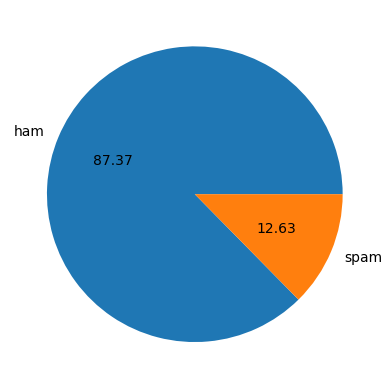

In [8]:
plt.pie(df["target"].value_counts(),labels=["ham","spam"],autopct="%0.2f")
plt.show()

## Feature Creation

In [9]:
df["num_characters"]=df["text"].apply(len)
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [10]:
df["num_words"]=df["text"].apply(lambda x:len(nltk.word_tokenize(x)))
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [11]:
df["num_sent"]=df["text"].apply(lambda x:len(nltk.sent_tokenize(x)))
df.head()

,target,text,num_characters,num_words,num_sent
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [12]:
df[df["target"]==0][["num_characters","num_words","num_sent"]].describe()

,num_characters,num_words,num_sent
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [13]:
df[df["target"]==1][["num_characters","num_words","num_sent"]].describe()

,num_characters,num_words,num_sent
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


## EDA based on new features

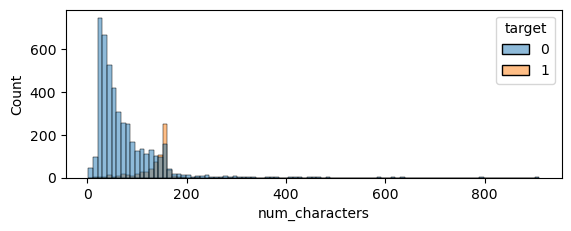

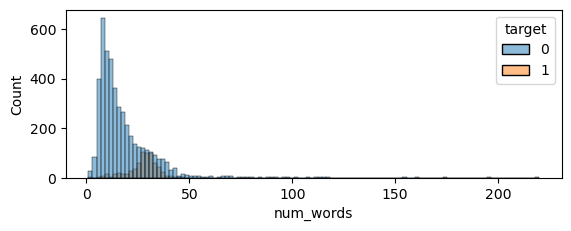

In [14]:
for n,i in enumerate(["num_characters","num_words"]):
    plt.subplot(2,1,n+1)
    sns.histplot(x=i,data=df,hue="target")
    plt.show()

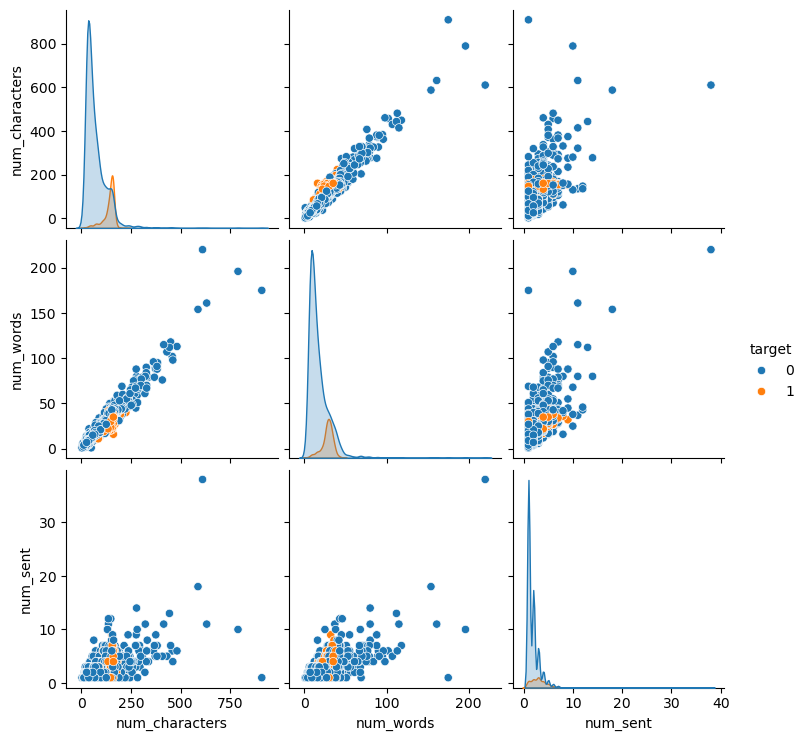

In [15]:
sns.pairplot(data=df,hue="target")
plt.show()

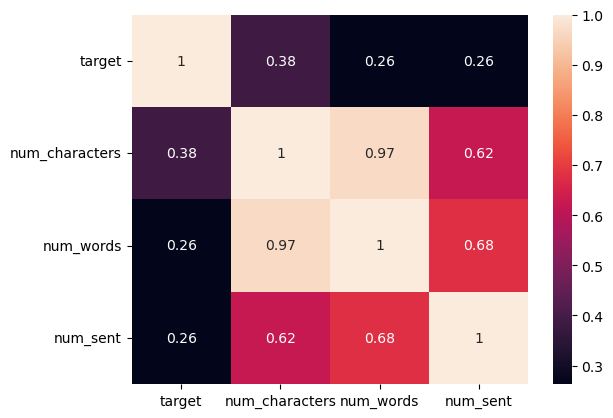

In [16]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

# Data preprocessing

## Text Preparation

In [47]:
from nltk.corpus import stopwords
stopwords=stopwords.words("english")

from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()

from nltk.stem import WordNetLemmatizer
wnl=WordNetLemmatizer()


In [18]:
def text_prep(x):
    # LowerCasing
    x=x.lower()
    # Tokenization
    x=nltk.word_tokenize(x)
    y=[]
    # Removing Special Characters
    for i in x:
        if i.isalnum():
            y.append(i)
    z=y[:]
    y.clear()
    # Removing Stopwords & Punctuations
    for i in z:
        if i not in stopwords and i not in string.punctuation:
            y.append(i)
    # Stemming
    z.clear()
    z=y[:]
    y.clear()
    for i in z:
        y.append(ps.stem(i))
    return " ".join(y)

In [19]:
df.head()

,target,text,num_characters,num_words,num_sent
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [40]:
df["prep_text"]=df["text"].apply(lambda x:text_prep(x))
df.head()

,target,text,num_characters,num_words,num_sent,prep_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


### EDA on each class label

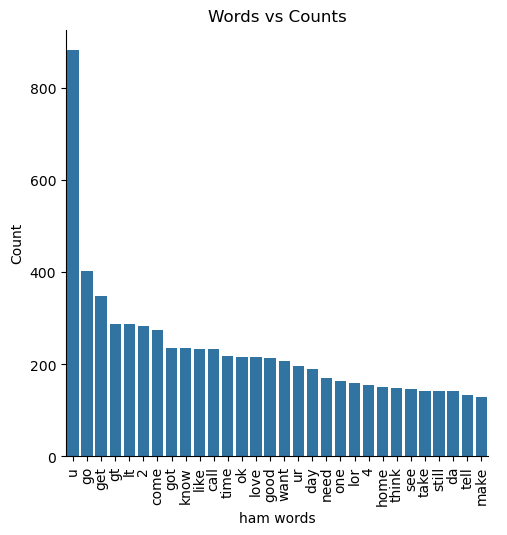

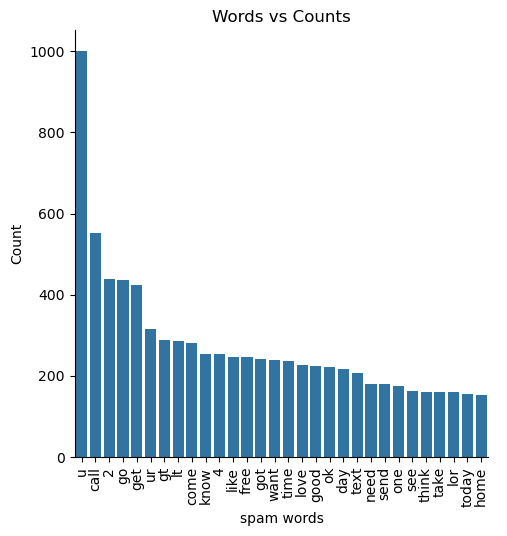

In [21]:
words=[]
for n,i in enumerate([[0,"ham words"],[1,"spam words"]]):
    for sent in df[df["target"]==i[0]]["prep_text"].to_list():
        for word in sent.split():
            words.append(word)
    most_app=Counter(words).most_common(30)
    most_app=pd.DataFrame(most_app)
    sns.catplot(x=most_app[0],y=most_app[1],data=most_app,kind="bar")
    plt.xlabel(i[1])
    plt.xticks(rotation="vertical")
    plt.ylabel("Count")
    plt.title("Words vs Counts")
    plt.show()           

In [39]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

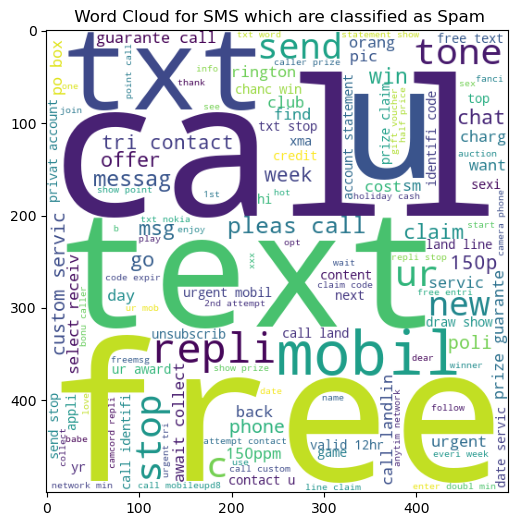

In [44]:
spam_wc=wc.generate(df[df['target'] == 1]['prep_text'].str.cat(sep=" "))
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)
plt.title(" Word Cloud for SMS which are classified as Spam")
plt.show()

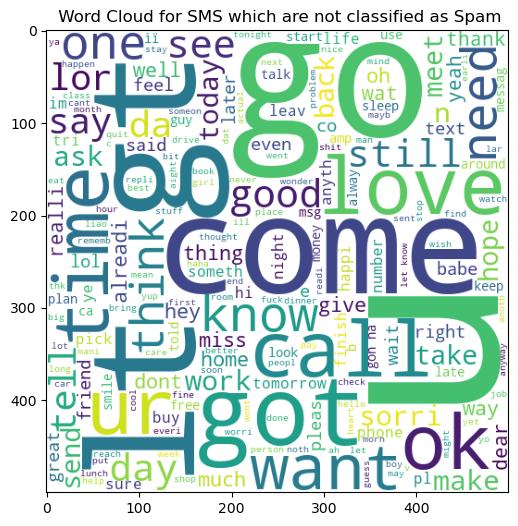

In [45]:
ham_wc=wc.generate(df[df['target'] == 0]['prep_text'].str.cat(sep=" "))
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)
plt.title(" Word Cloud for SMS which are not classified as Spam")
plt.show()

## Text vectorisation

In [95]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer(max_features=3000)
x=tfidf.fit_transform(df["prep_text"])
y=df["target"].values

## Train Test Split

In [23]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8,random_state=2)

# Finding Best Model

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier,ExtraTreesClassifier,BaggingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [25]:
svm = SVC(kernel='sigmoid', gamma=1.0)
knn = KNeighborsClassifier()
nb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lor = LogisticRegression(solver='liblinear', penalty='l1')
rf = RandomForestClassifier(n_estimators=50, random_state=2)
adb = AdaBoostClassifier(n_estimators=50, random_state=2)
bag = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbc = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [26]:
clf={
    "Decision Tree":dtc,
    "Logistic":lor,
    "Random Forest":rf,
    "AdaBoost":adb,
    "Gradient Boostring":gbc,
    "Extra Trees":etc,
    "Bagging":bag,
    "XGBoost":xgb,
    "SVM":svm,
    "Naive Bayes":nb,
    "KNN":knn}

In [27]:
def model(clf,x_train,x_test,y_train,y_test):
    clf.fit(x_train,y_train)
    y_pred=clf.predict(x_test)
    return accuracy_score(y_test,y_pred),precision_score(y_test,y_pred)

In [28]:
acc=[]
prec=[]
name=[]
for n,i in clf.items():
    print(i)
    accuracy,precision=model(i,x_train,x_test,y_train,y_test)
    acc.append(accuracy)
    prec.append(precision)
    name.append(n)

DecisionTreeClassifier(max_depth=5)
LogisticRegression(penalty='l1', solver='liblinear')
RandomForestClassifier(n_estimators=50, random_state=2)
AdaBoostClassifier(random_state=2)
GradientBoostingClassifier(n_estimators=50, random_state=2)
ExtraTreesClassifier(n_estimators=50, random_state=2)
BaggingClassifier(n_estimators=50, random_state=2)
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strate

In [29]:
result=pd.DataFrame({"Classifier":name,"Accuracy":acc,"Precision":prec})
result.sort_values(by="Precision",ascending=False)

,Classifier,Accuracy,Precision
9,Naive Bayes,0.970986,1.000000
10,KNN,0.905222,1.000000
2,Random Forest,0.975822,0.982906
8,SVM,0.975822,0.974790
5,Extra Trees,0.974855,0.974576
1,Logistic,0.958414,0.970297
7,XGBoost,0.969052,0.956897
3,AdaBoost,0.960348,0.929204
4,Gradient Boostring,0.946809,0.919192
6,Bagging,0.958414,0.868217


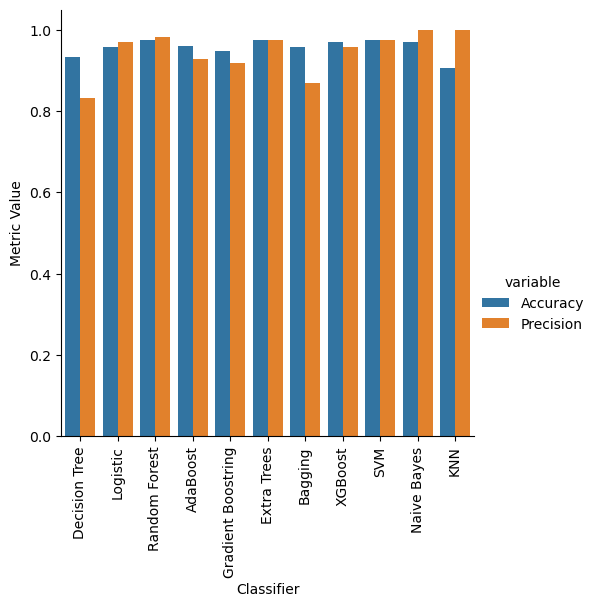

In [30]:
results_1 = pd.melt(result, id_vars = "Classifier")
sns.catplot(x="Classifier",y="value",data=results_1,hue="variable",kind="bar")
plt.xticks(rotation='vertical')
plt.ylabel("Metric Value")
plt.show()

#### Hence, Naive Bayes model performs well on this data with highest precision and accuracy accordingly.

# Fitting Best Model

In [50]:
model=MultinomialNB()
model.fit(x_train,y_train)
y_pred_best=model.predict(x_test)
print("Accuracy of Model is ",accuracy_score(y_test,y_pred_best))
print("Precision Score of Model is ",precision_score(y_test,y_pred_best))

Accuracy of Model is  0.9709864603481625
Precision Score of Model is  1.0


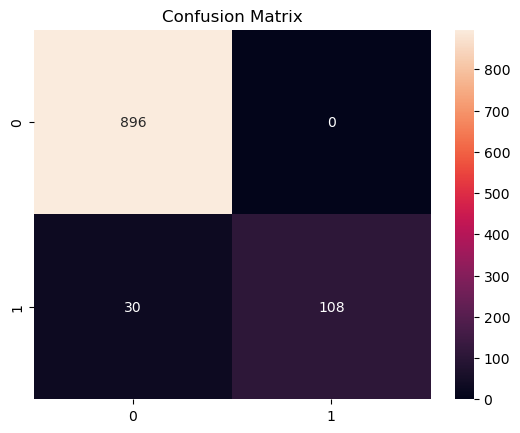

In [96]:
sns.heatmap(confusion_matrix(y_test,y_pred_best),annot=True,fmt='g')
plt.title("Confusion Matrix")
plt.show()

### Testing on actual data

In [101]:
x_new="Hi Kaustubh,Thank you for your interest in our Data Scientist/Data Analyst (448303) position.We're currently reviewing resumes with our hiring manager and will notify you once we have an update. You can also follow your progress within your Siemens account, or find and apply for more opportunities to change the future with Siemens."
test_x=text_prep(x_new); test_x
prep_x=tfidf.transform([test_x])
model.predict(prep_x)

array([0])

In [108]:
xn = "Dear students from PVG's College Of Engineering. CODEIOX-ED IN COLLABORATION WITH  WIPRO DICE ID is organising a  2-month training + Internship program with certifications in technical and non-technical domains. We are enrolling SHORTLISTED STUDENTS in the program Note: If any of your batchmates are missed or haven't received the notification, recipients can send this mail to them. Students must submit their application. After getting shortlisted, you will be getting a response from our team: Submit your Application https://forms.gle/rRR1KkUkm3tgjwaJ7 Join Our Official WHATSAPP Group For More Information: https://whatsapp.com/channel/0029Var5miB05MUliegmWq1L [THIS NOTIFICATION FOR THE ENROLLMENT OF   JAN-FEB, FEB -MAR & MAR - APR  BATCHES FOR STUDENTS WHO HAVEN'T BEEN ABLE TO ACCEPT THE SCHOLARSHIP SLOT FOR THE SAME.]"
tx=text_prep(xn); tx
px=tfidf.transform([tx])
model.predict(px)

array([0])

# Extracting Files for Model Deployment

In [49]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(nb,open('model.pkl','wb'))